# Classificação de Risco de Crédito

Previsão de dificuldades de pagamento utilizando aprendizagem de máquina.

## 1. Visão Geral do Projeto

A análise de risco de crédito é uma importante aplicação de aprendizagem de máquina em instituições financeiras. A identificação de solicitações associadas a uma maior possibilidade de dificuldade de pagamento pode auxiliar a análise de risco e apoiar decisões mais informadas.

O objetivo deste projeto é desenvolver e comparar dois modelos supervisionados para classificação de risco de crédito:

- uma Rede Neural;
- uma Árvore de Decisão regularizada por meio do algoritmo de Minimal Cost-Complexity Pruning.

O projeto contemplará as seguintes etapas:

1. inspeção e limpeza dos dados;
2. análise exploratória;
3. engenharia de atributos;
4. construção da matriz de características \(X\) e do vetor-alvo \(y\);
5. separação dos dados em treinamento, validação e teste;
6. pré-processamento das variáveis numéricas e categóricas;
7. definição e treinamento da arquitetura da Rede Neural;
8. análise de \(E_{in}\), \(E_{out}\) e overfitting;
9. treinamento e regularização da Árvore de Decisão utilizando `ccp_alpha`;
10. avaliação dos modelos utilizando acurácia, precisão, recall e F1-score;
11. comparação e escolha do modelo com melhor capacidade de generalização.

Na primeira etapa, serão utilizadas apenas as informações presentes na solicitação atual de crédito. Após a conclusão dos modelos obrigatórios, poderão ser incorporadas informações históricas de solicitações anteriores e registros externos de crédito, com o objetivo de verificar se esses dados adicionais melhoram o desempenho preditivo.

## 2. Descrição do Conjunto de Dados

Este projeto utiliza o conjunto de dados **Home Credit Default Risk**, originalmente disponibilizado em uma competição de aprendizagem de máquina no Kaggle.

A base contém informações anonimizadas sobre solicitantes de crédito, características das solicitações atuais, solicitações anteriores e registros de crédito mantidos por outras instituições.

O principal arquivo utilizado na primeira versão do projeto será:

- `application_train.csv`: contém uma linha para cada solicitação de crédito, características do solicitante, informações financeiras e a variável-alvo `TARGET`.

Posteriormente, poderão ser incorporadas duas tabelas auxiliares:

- `bureau.csv`: contém informações sobre créditos anteriores registrados por outras instituições financeiras;
- `previous_application.csv`: contém solicitações de crédito anteriores realizadas pelos mesmos clientes.

A coluna `SK_ID_CURR` identifica cada cliente e permite relacionar a tabela principal às tabelas auxiliares.

O conjunto de dados contém variáveis numéricas e categóricas relacionadas a:

- renda do solicitante;
- valor do crédito solicitado;
- valor da parcela;
- idade e tempo de emprego;
- composição familiar;
- escolaridade;
- características da moradia;
- tipo de renda;
- tipo e finalidade da solicitação;
- pontuações externas de risco.

Os arquivos brutos estão armazenados localmente na pasta `data/raw/`. Eles não são enviados ao repositório do GitHub devido ao tamanho dos arquivos e estão protegidos pelas regras definidas no `.gitignore`.

A primeira etapa experimental utilizará somente o arquivo `application_train.csv`. As tabelas auxiliares serão agrupadas pela coluna `SK_ID_CURR` antes de serem adicionadas à tabela principal, evitando a duplicação de clientes que possuem vários registros históricos.

## 3. Definição do Problema

Este projeto será tratado como um problema supervisionado de classificação binária.

O objetivo é utilizar informações disponíveis sobre o solicitante e a solicitação de crédito para prever a classe associada à dificuldade de pagamento, conforme a definição adotada pelo conjunto de dados Home Credit Default Risk.

A variável-alvo \(y\) corresponde à coluna `TARGET`:

$$
y = \texttt{TARGET}
$$

em que:

- `TARGET = 0`: solicitação não associada à classe de dificuldade de pagamento;
- `TARGET = 1`: solicitação associada à classe de dificuldade de pagamento.

A matriz de características \(X\) será formada pelas informações do solicitante e da solicitação de crédito:

$$
X = \text{características do solicitante e da solicitação de crédito}
$$

As colunas `TARGET` e `SK_ID_CURR` não serão utilizadas como características de entrada dos modelos:

- `TARGET` representa a variável que será prevista;
- `SK_ID_CURR` é apenas o identificador de cada cliente.

A principal pergunta investigada será:

> É possível utilizar informações do solicitante e da solicitação de crédito para identificar casos associados à dificuldade de pagamento?

Após a conclusão da primeira versão do projeto, também poderá ser investigada a seguinte pergunta complementar:

> A inclusão de informações sobre créditos e solicitações anteriores melhora o desempenho dos modelos?

Serão desenvolvidos e comparados dois modelos de classificação:

1. uma Rede Neural;
2. uma Árvore de Decisão regularizada por Minimal Cost-Complexity Pruning.

Os dados serão separados em conjuntos de treinamento, validação e teste. As decisões relacionadas à arquitetura da Rede Neural, ao número de épocas, ao batch size, ao valor de `ccp_alpha` e aos demais hiperparâmetros serão tomadas utilizando apenas os conjuntos de treinamento e validação.

O conjunto de teste permanecerá isolado durante o desenvolvimento e será utilizado somente na avaliação final dos modelos.

Como a classe `TARGET = 1` pode ser menos frequente, a acurácia não será utilizada isoladamente. Os modelos serão avaliados por meio das seguintes métricas:

- acurácia;
- precisão;
- recall;
- F1-score;
- matriz de confusão.

A classe positiva será definida como `TARGET = 1`. O recall terá atenção especial, pois representa a proporção de casos da classe de dificuldade de pagamento corretamente identificados pelo modelo.

Este projeto consiste em uma análise acadêmica de modelos de aprendizagem de máquina. Os resultados não devem ser interpretados como um sistema automático de aprovação ou rejeição de crédito.

## 4. Importação das Bibliotecas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

candidate_roots = [Path.cwd(), Path.cwd().parent]

repo_root = next(
    (
        root
        for root in candidate_roots
        if (root / "data" / "raw").is_dir()
    ),
    None,
)

if repo_root is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto. "
        "Abra o notebook pela raiz do repositório ou pela pasta notebooks."
    )

DATA_PATH = repo_root / "data" / "raw"
FIGURES_PATH = repo_root / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


## 5. Carregamento dos Dados

In [2]:
application_path = DATA_PATH / 'application_train.csv'

if not application_path.exists():
    raise FileNotFoundError(
        'Arquivo application_train.csv não encontrado em data/raw/.'
    )

application = pd.read_csv(application_path)

relative_application_path = application_path.relative_to(repo_root)
print(f'Dados carregados: {relative_application_path}')

Dados carregados: data\raw\application_train.csv


### 5.1 Inspeção Inicial

In [3]:
required_columns = {'SK_ID_CURR', 'TARGET'}
missing_columns = required_columns.difference(application.columns)

if missing_columns:
    raise ValueError(
        f'Colunas obrigatórias ausentes: {sorted(missing_columns)}'
    )

target_missing_count = application['TARGET'].isna().sum()

if target_missing_count > 0:
    raise ValueError(
        f'A coluna TARGET possui {target_missing_count} valores ausentes.'
    )

target_values = set(application['TARGET'].unique())

if not target_values.issubset({0, 1}):
    raise ValueError(
        f'Valores inesperados na coluna TARGET: {sorted(target_values)}'
    )

target_values_display = sorted(
    int(value) for value in target_values
)

print(f'Quantidade de linhas: {application.shape[0]:,}')
print(f'Quantidade de colunas: {application.shape[1]:,}')
print(f'Quantidade de linhas duplicadas: {application.duplicated().sum():,}')
print(f'Quantidade total de valores ausentes: {application.isna().sum().sum():,}')
print(f'Colunas obrigatórias confirmadas: {sorted(required_columns)}')
print(
    f'Valores encontrados em TARGET: '
    f'{target_values_display}'
)

Quantidade de linhas: 307,511
Quantidade de colunas: 122
Quantidade de linhas duplicadas: 0
Quantidade total de valores ausentes: 9,152,465
Colunas obrigatórias confirmadas: ['SK_ID_CURR', 'TARGET']
Valores encontrados em TARGET: [0, 1]


## 6. Análise Exploratória dos Dados

### 6.1 Estrutura Geral da Base

Esta inspeção resume a dimensão, os tipos de variáveis e o uso aproximado de memória da base sem listar individualmente todas as colunas.

In [4]:
numerical_columns = application.select_dtypes(include=np.number).columns
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
dtype_counts = (
    application.dtypes.astype(str)
    .value_counts()
    .rename_axis('tipo')
    .to_frame('quantidade')
)
memory_usage_mb = application.memory_usage(deep=True).sum() / (1024 ** 2)

display(application.head())
print(f'Quantidade de variáveis numéricas: {len(numerical_columns)}')
print(f'Quantidade de variáveis categóricas: {len(categorical_columns)}')
display(dtype_counts)
print(f'Memória aproximada utilizada: {memory_usage_mb:.2f} MB')

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Quantidade de variáveis numéricas: 106
Quantidade de variáveis categóricas: 16


,quantidade
tipo,
float64,65
int64,41
str,16


Memória aproximada utilizada: 536.69 MB


A base possui 307.511 registros e 122 colunas: 106 variáveis numéricas e 16 categóricas. Foram observadas 65 colunas `float64`, 41 `int64` e 16 `str`, com uso aproximado de 536,69 MB de memória.

### 6.2 Distribuição da Variável-Alvo

,quantidade,proporcao,percentual
TARGET,,,
0,282686,0.919271,91.927118
1,24825,0.080729,8.072882


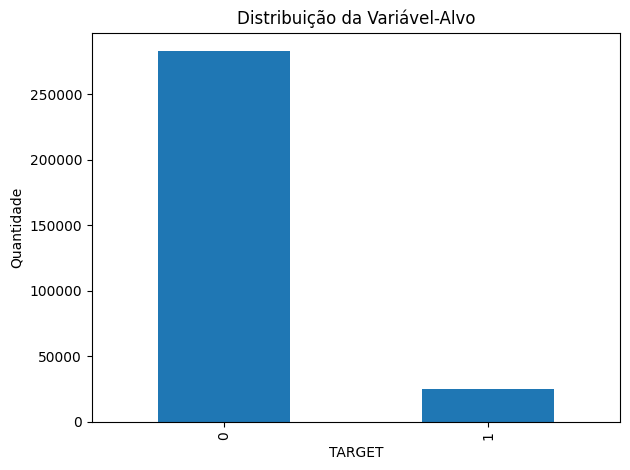

In [5]:
target_distribution = (
    application['TARGET']
    .value_counts()
    .sort_index()
    .rename('quantidade')
    .to_frame()
)
target_distribution['proporcao'] = (
    target_distribution['quantidade'] / len(application)
)
target_distribution['percentual'] = (
    target_distribution['proporcao'] * 100
)

display(target_distribution)

target_distribution['quantidade'].plot(kind='bar')
plt.title('Distribuição da Variável-Alvo')
plt.xlabel('TARGET')
plt.ylabel('Quantidade')
plt.tight_layout()
target_distribution_path = FIGURES_PATH / 'target_distribution.png'
plt.savefig(target_distribution_path)
plt.show()
plt.close()

Foram observadas 282.686 ocorrências de `TARGET = 0` (91,93%) e 24.825 de `TARGET = 1` (8,07%). A distribuição é desbalanceada, mas nenhum balanceamento foi aplicado nesta etapa.

### 6.3 Valores Ausentes

,quantidade,percentual
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


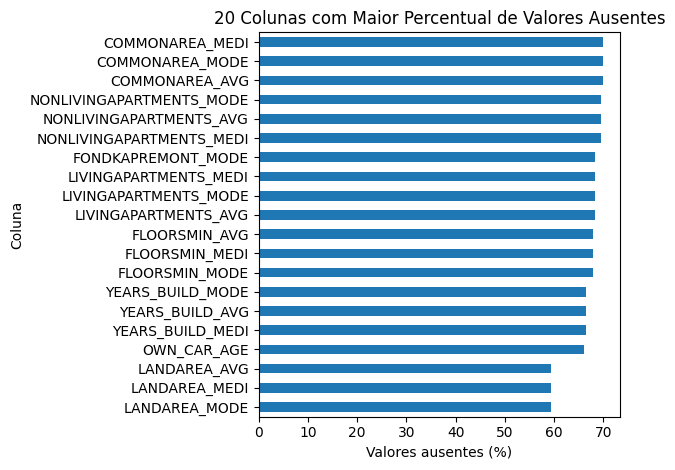

In [6]:
missing_values = pd.DataFrame({
    'quantidade': application.isna().sum(),
    'percentual': application.isna().mean() * 100,
})
top_missing_values = (
    missing_values.loc[missing_values['quantidade'] > 0]
    .nlargest(20, 'percentual')
)

display(top_missing_values)

top_missing_values.sort_values('percentual').plot.barh(
    y='percentual',
    legend=False,
)
plt.title('20 Colunas com Maior Percentual de Valores Ausentes')
plt.xlabel('Valores ausentes (%)')
plt.ylabel('Coluna')
plt.tight_layout()
top_missing_values_path = FIGURES_PATH / 'top_missing_values.png'
plt.savefig(top_missing_values_path)
plt.show()
plt.close()

Nas 20 colunas exibidas, os percentuais de ausência variam de 59,38% a 69,87%. `COMMONAREA_AVG`, `COMMONAREA_MODE` e `COMMONAREA_MEDI` apresentam o maior percentual observado, de 69,87%; nenhum valor foi removido ou imputado.

### 6.4 Resumo das Variáveis Numéricas

In [7]:
numeric_columns_of_interest = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]
available_numeric_columns = [
    column
    for column in numeric_columns_of_interest
    if column in application.columns
]
numeric_summary = application[available_numeric_columns].describe().T

display(numeric_summary)

if 'DAYS_EMPLOYED' in application.columns:
    special_days_employed_count = int(
        application['DAYS_EMPLOYED'].eq(365243).sum()
    )
    print(
        'Ocorrências do valor 365243 em DAYS_EMPLOYED: '
        f'{special_days_employed_count:,}'
    )
else:
    print('A coluna DAYS_EMPLOYED não está presente na base.')

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


Ocorrências do valor 365243 em DAYS_EMPLOYED: 55,374


As oito variáveis numéricas selecionadas estão presentes na base. Em `DAYS_EMPLOYED`, o valor especial `365243` ocorre 55.374 vezes; ele foi apenas identificado, sem substituição ou limpeza.

### 6.5 Resumo das Variáveis Categóricas

In [8]:
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
categorical_rows = []

for column in categorical_columns:
    category_counts = application[column].value_counts(dropna=True)
    categorical_rows.append({
        'variavel': column,
        'categorias_distintas': application[column].nunique(dropna=True),
        'categoria_mais_frequente': (
            category_counts.index[0] if not category_counts.empty else pd.NA
        ),
        'frequencia_categoria_mais_frequente': (
            int(category_counts.iloc[0]) if not category_counts.empty else 0
        ),
        'valores_ausentes': int(application[column].isna().sum()),
    })

categorical_summary = (
    pd.DataFrame(
        categorical_rows,
        columns=[
            'variavel',
            'categorias_distintas',
            'categoria_mais_frequente',
            'frequencia_categoria_mais_frequente',
            'valores_ausentes',
        ],
    )
    .set_index('variavel')
    .sort_values('categorias_distintas', kind='stable')
    .head(20)
)

display(categorical_summary)

,categorias_distintas,categoria_mais_frequente,frequencia_categoria_mais_frequente,valores_ausentes
variavel,,,,
NAME_CONTRACT_TYPE,2,Cash loans,278232,0
FLAG_OWN_CAR,2,N,202924,0
FLAG_OWN_REALTY,2,Y,213312,0
EMERGENCYSTATE_MODE,2,No,159428,145755
CODE_GENDER,3,F,202448,0
HOUSETYPE_MODE,3,block of flats,150503,154297
FONDKAPREMONT_MODE,4,reg oper account,73830,210295
NAME_EDUCATION_TYPE,5,Secondary / secondary special,218391,0
NAME_FAMILY_STATUS,6,Married,196432,0


Foram identificadas 16 variáveis categóricas, com 2 a 58 categorias distintas. A tabela mostra todas elas por estarem dentro do limite de 20 e evidencia que algumas possuem valores ausentes; nenhuma codificação ou agregação foi aplicada.

## 7. Limpeza dos Dados e Engenharia de Atributos

### 7.1 Cópia de Trabalho e Correções Determinísticas

A limpeza é realizada em uma cópia da base para preservar os dados brutos. Nesta etapa são corrigidos apenas códigos com significado conhecido: `365243` em `DAYS_EMPLOYED`, que representa ausência de informação, e `XNA` em `CODE_GENDER`, que não corresponde a uma categoria válida. Duplicatas exatas também são verificadas.

Valores ausentes, categorias raras e colunas com alta ausência não são removidos ou imputados aqui, pois essas decisões deverão ser ajustadas somente após a separação dos dados.

In [9]:
application_clean = application.copy()

duplicate_rows_before = int(application_clean.duplicated().sum())

if duplicate_rows_before > 0:
    application_clean = (
        application_clean
        .drop_duplicates()
        .reset_index(drop=True)
    )

days_employed_special_count = 0

if 'DAYS_EMPLOYED' in application_clean.columns:
    days_employed_special_mask = application_clean['DAYS_EMPLOYED'].eq(365243)
    days_employed_special_count = int(days_employed_special_mask.sum())
    application_clean.loc[
        days_employed_special_mask,
        'DAYS_EMPLOYED',
    ] = np.nan

code_gender_xna_count = 0

if 'CODE_GENDER' in application_clean.columns:
    code_gender_xna_mask = application_clean['CODE_GENDER'].eq('XNA')
    code_gender_xna_count = int(code_gender_xna_mask.sum())
    application_clean.loc[
        code_gender_xna_mask,
        'CODE_GENDER',
    ] = pd.NA

print(f'Linhas duplicadas removidas: {duplicate_rows_before:,}')
print(
    'Valores 365243 convertidos em ausentes em DAYS_EMPLOYED: '
    f'{days_employed_special_count:,}'
)
print(
    'Categorias XNA convertidas em ausentes em CODE_GENDER: '
    f'{code_gender_xna_count:,}'
)
print(
    f'Dimensão após a limpeza determinística: '
    f'{application_clean.shape[0]:,} linhas x '
    f'{application_clean.shape[1]:,} colunas'
)

Linhas duplicadas removidas: 0
Valores 365243 convertidos em ausentes em DAYS_EMPLOYED: 55,374
Categorias XNA convertidas em ausentes em CODE_GENDER: 4
Dimensão após a limpeza determinística: 307,511 linhas x 122 colunas


Não foram encontradas linhas duplicadas. Foram convertidas em ausentes 55.374 ocorrências de `365243` em `DAYS_EMPLOYED` e 4 ocorrências de `XNA` em `CODE_GENDER`. A base permaneceu com 307.511 linhas e 122 colunas.

### 7.2 Engenharia de Atributos

São criados sete atributos com interpretação demográfica ou financeira: idade e tempo de emprego em anos, relações entre crédito, parcela e renda, além de medidas ajustadas pelo tamanho da família. Divisões por zero são tratadas como valores ausentes, sem imputação.

In [10]:
feature_source_columns = {
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'CNT_FAM_MEMBERS',
    'CNT_CHILDREN',
}
missing_feature_sources = feature_source_columns.difference(
    application_clean.columns
)

if missing_feature_sources:
    raise ValueError(
        'Colunas necessárias para engenharia de atributos ausentes: '
        f'{sorted(missing_feature_sources)}'
    )

def safe_ratio(numerator, denominator):
    denominator_without_zero = denominator.mask(denominator.eq(0))
    return numerator.div(denominator_without_zero)

application_clean['AGE_YEARS'] = (
    -application_clean['DAYS_BIRTH'] / 365.25
)
application_clean['EMPLOYMENT_YEARS'] = (
    -application_clean['DAYS_EMPLOYED'] / 365.25
)
application_clean['CREDIT_INCOME_RATIO'] = safe_ratio(
    application_clean['AMT_CREDIT'],
    application_clean['AMT_INCOME_TOTAL'],
)
application_clean['ANNUITY_INCOME_RATIO'] = safe_ratio(
    application_clean['AMT_ANNUITY'],
    application_clean['AMT_INCOME_TOTAL'],
)
application_clean['CREDIT_PER_FAMILY_MEMBER'] = safe_ratio(
    application_clean['AMT_CREDIT'],
    application_clean['CNT_FAM_MEMBERS'],
)
application_clean['CHILDREN_PER_FAMILY_MEMBER'] = safe_ratio(
    application_clean['CNT_CHILDREN'],
    application_clean['CNT_FAM_MEMBERS'],
)
application_clean['CREDIT_ANNUITY_RATIO'] = safe_ratio(
    application_clean['AMT_CREDIT'],
    application_clean['AMT_ANNUITY'],
)

engineered_features = [
    'AGE_YEARS',
    'EMPLOYMENT_YEARS',
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_PER_FAMILY_MEMBER',
    'CHILDREN_PER_FAMILY_MEMBER',
    'CREDIT_ANNUITY_RATIO',
]
engineered_feature_quality = pd.DataFrame({
    'valores_ausentes': application_clean[engineered_features].isna().sum(),
    'valores_infinitos': np.isinf(
        application_clean[engineered_features]
    ).sum(),
})

print(f'Atributos criados: {len(engineered_features)}')
print(
    f'Dimensão após a engenharia de atributos: '
    f'{application_clean.shape[0]:,} linhas x '
    f'{application_clean.shape[1]:,} colunas'
)
display(engineered_feature_quality)

Atributos criados: 7
Dimensão após a engenharia de atributos: 307,511 linhas x 129 colunas


,valores_ausentes,valores_infinitos
AGE_YEARS,0,0
EMPLOYMENT_YEARS,55374,0
CREDIT_INCOME_RATIO,0,0
ANNUITY_INCOME_RATIO,12,0
CREDIT_PER_FAMILY_MEMBER,2,0
CHILDREN_PER_FAMILY_MEMBER,2,0
CREDIT_ANNUITY_RATIO,12,0


Foram adicionados sete atributos, elevando a base para 129 colunas. Nenhum atributo derivado apresentou valor infinito. Os valores ausentes observados decorrem das informações originais indisponíveis, com destaque para as 55.374 ausências de `EMPLOYMENT_YEARS` após a correção do código especial.

### 7.3 Verificação das Transformações

As estatísticas descritivas dos novos atributos são verificadas para confirmar a escala das variáveis e a ausência dos códigos especiais tratados.

In [11]:
engineered_feature_summary = (
    application_clean[engineered_features]
    .describe()
    .T
)
remaining_infinite_values = int(
    np.isinf(application_clean[engineered_features]).sum().sum()
)
remaining_days_employed_special = int(
    application_clean['DAYS_EMPLOYED'].eq(365243).sum()
)
remaining_code_gender_xna = int(
    application_clean['CODE_GENDER'].eq('XNA').sum()
)

display(engineered_feature_summary)
print(f'Valores infinitos nos atributos criados: {remaining_infinite_values:,}')
print(
    'Valores 365243 restantes em DAYS_EMPLOYED: '
    f'{remaining_days_employed_special:,}'
)
print(
    'Categorias XNA restantes em CODE_GENDER: '
    f'{remaining_code_gender_xna:,}'
)

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,307511.0,43.906900,11.947950,20.503765,33.984942,43.121150,53.886379,6.907324e+01
EMPLOYMENT_YEARS,252137.0,6.527500,6.402081,-0.000000,2.099932,4.511978,8.692676,4.904038e+01
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_PER_FAMILY_MEMBER,307509.0,323949.587662,259087.050339,6750.000000,135533.250000,255051.000000,437370.000000,4.031032e+06
CHILDREN_PER_FAMILY_MEMBER,307509.0,0.125502,0.199578,0.000000,0.000000,0.000000,0.333333,9.500000e-01
CREDIT_ANNUITY_RATIO,307499.0,21.612322,7.823823,8.036674,15.614496,20.000000,27.099985,4.530508e+01


Valores infinitos nos atributos criados: 0
Valores 365243 restantes em DAYS_EMPLOYED: 0
Categorias XNA restantes em CODE_GENDER: 0


A idade calculada varia de aproximadamente 20,50 a 69,07 anos, e o tempo de emprego válido chega a 49,04 anos. Não restaram valores infinitos nos atributos criados, códigos `365243` em `DAYS_EMPLOYED` ou categorias `XNA` em `CODE_GENDER`. Nenhuma imputação foi realizada.

## 8. Construção de X e y

### 8.1 Separação entre Características e Variável-Alvo

A matriz `X` é construída a partir da base limpa e enriquecida, excluindo `TARGET`, que constitui a variável-alvo `y`, e `SK_ID_CURR`, que é apenas um identificador. Esta etapa ainda não divide os dados nem aplica imputação, codificação ou padronização.

In [ ]:
columns_excluded_from_X = {
    'TARGET',
    'SK_ID_CURR',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
}

missing_excluded_columns = columns_excluded_from_X.difference(
    application_clean.columns
)

if missing_excluded_columns:
    raise ValueError(
        f'Colunas esperadas não encontradas: {sorted(missing_excluded_columns)}'
    )

X = application_clean.drop(
    columns=sorted(columns_excluded_from_X)
).copy()

y = application_clean['TARGET'].copy()

# Verificações de integridade
if columns_excluded_from_X.intersection(X.columns):
    raise ValueError(
        'Uma ou mais colunas que deveriam ser excluídas permaneceram em X.'
    )

if y.isna().any():
    raise ValueError('A variável TARGET possui valores ausentes.')

if set(y.unique()) != {0, 1}:
    raise ValueError(
        f'Valores inesperados em TARGET: {sorted(y.unique())}'
    )

X_numerical_count = X.select_dtypes(include=np.number).shape[1]
X_categorical_count = X.select_dtypes(
    include=['object', 'category', 'string']
).shape[1]

y_distribution = (
    y.value_counts()
    .sort_index()
    .to_frame(name='quantidade')
)

y_distribution['proporcao'] = (
    y_distribution['quantidade'] / len(y)
)

print(
    f'Dimensão de X: {X.shape[0]:,} linhas x '
    f'{X.shape[1]:,} colunas'
)

print(f'Dimensão de y: {y.shape[0]:,} valores')

print(
    f'Variáveis numéricas em X: {X_numerical_count:,}'
)

print(
    f'Variáveis categóricas em X: {X_categorical_count:,}'
)

print(
    'Colunas excluídas de X confirmadas: '
    f'{sorted(columns_excluded_from_X)}'
)

display(y_distribution)

MemoryError: Unable to allocate 171. MiB for an array with shape (73, 307511) and data type float64

`X` possui 307.511 amostras e 127 características, sendo 111 numéricas e 16 categóricas. `y` possui 307.511 valores binários, com a distribuição original preservada. Os 9.263.245 valores ausentes em `X` foram mantidos para tratamento posterior com procedimentos ajustados somente nos dados de treinamento.

## 9. Divisão em Treinamento, Validação e Teste

## 10. Pré-processamento dos Dados

## 11. Rede Neural

## 12. Árvore de Decisão e Poda por Complexidade de Custo

## 13. Comparação dos Modelos

## 14. Conclusões